In one hot encoding 
<br> we represent every variable with a vector 
<br> for eg [blue,green,red]
<br> so blue=[1,0,0],
<br> green=[0,1,0]
<br> red=[0,0,1]

Dummy variable Trap
<br>
we dont want our input cols to have a mathematical relationship cause that affects
<br>
some ML algorithum<br>
so we only take n-1 columns to prevent the problem of multicollinearity<br>

<br> removing one col doesnt affects others as we know that the last one has to be
<br> the else case
<br>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv(r"d:\Downloads_ML_aaa\cars.csv")
df.head()


,brand,km_driven,fuel,owner,selling_price
0,Maruti,145500,Diesel,First Owner,450000
1,Skoda,120000,Diesel,Second Owner,370000
2,Honda,140000,Petrol,Third Owner,158000
3,Hyundai,127000,Diesel,First Owner,225000
4,Maruti,120000,Petrol,First Owner,130000


In [2]:
df["brand"].value_counts()
print(df["brand"].nunique())

32


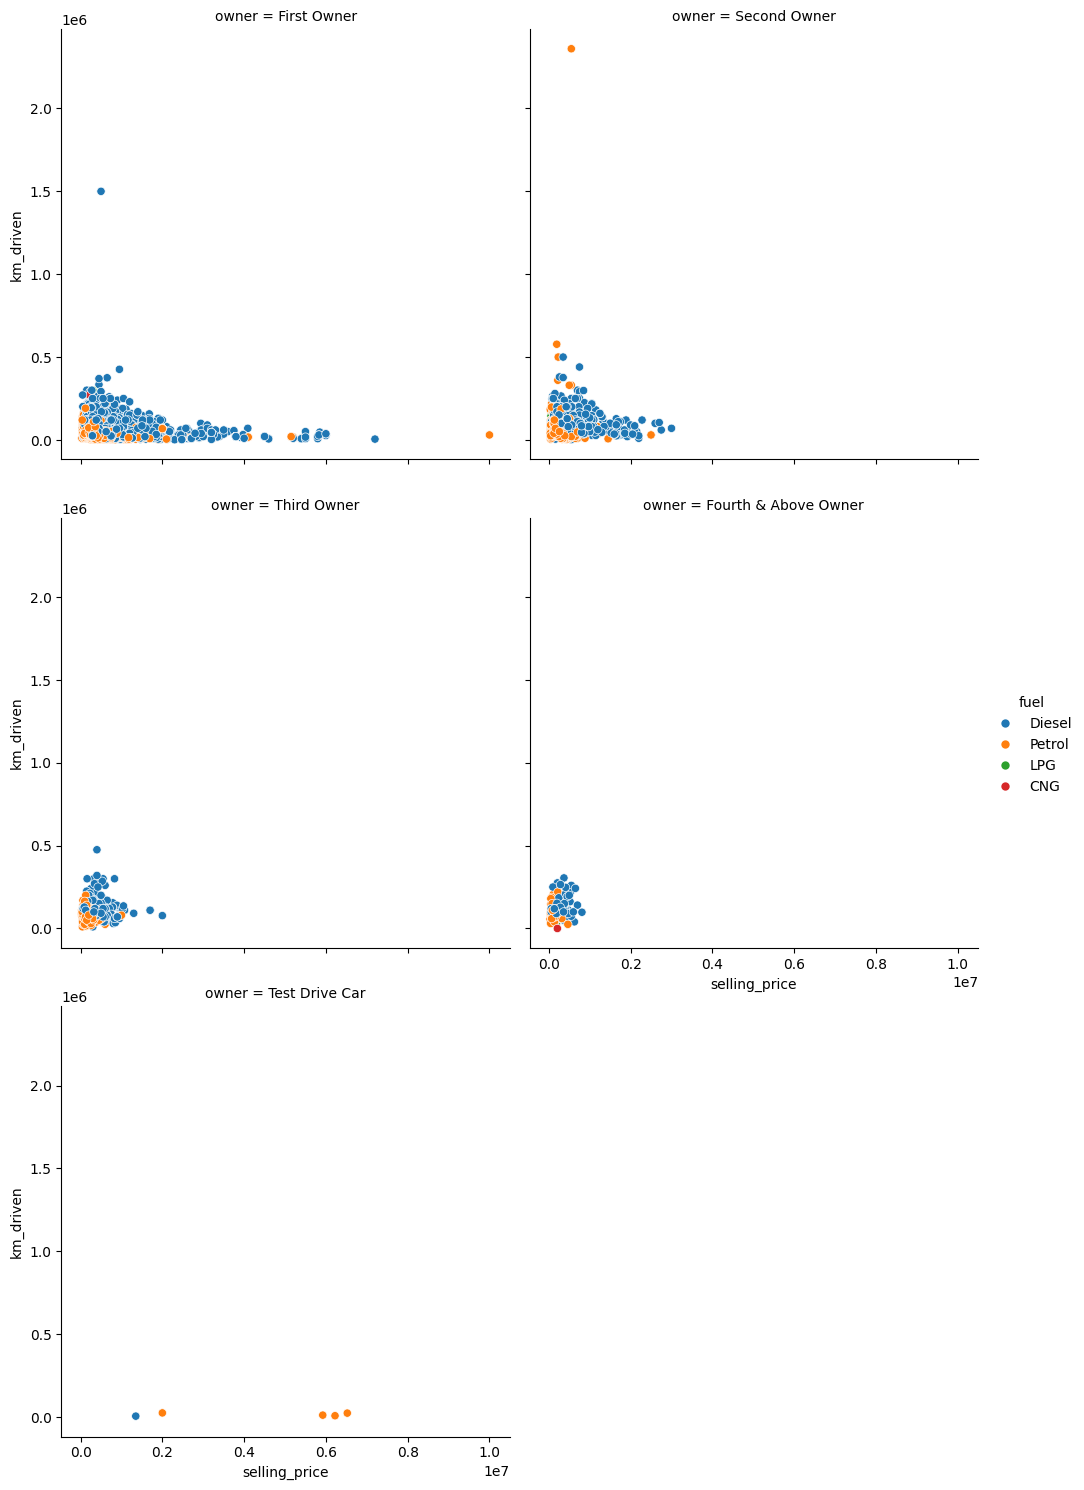

In [3]:
sns.relplot(df,x="selling_price",y="km_driven",
            hue="fuel",
            col="owner",col_wrap=2,kind="scatter")

<Axes: xlabel='count', ylabel='brand'>

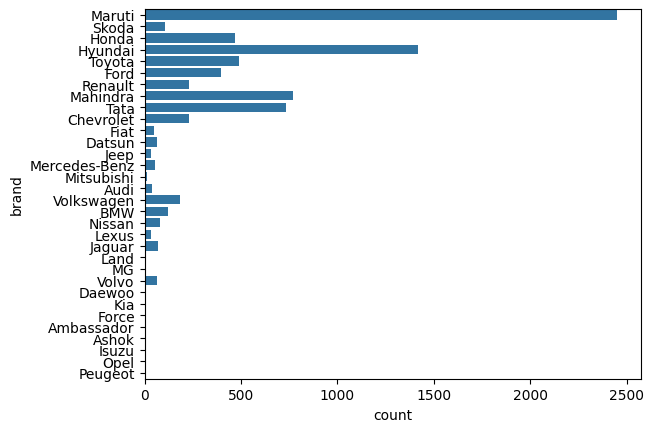

In [4]:
sns.countplot(df["brand"])

## One hot encodig using Pandas
<br> no inplace change in original table 

In [5]:
pd.get_dummies(df,columns=["fuel","owner"],dtype=int)

,brand,km_driven,selling_price,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,0,1,0,0,1,0,0,0,0
1,Skoda,120000,370000,0,1,0,0,0,0,1,0,0
2,Honda,140000,158000,0,0,0,1,0,0,0,0,1
3,Hyundai,127000,225000,0,1,0,0,1,0,0,0,0
4,Maruti,120000,130000,0,0,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,0,0,0,1,1,0,0,0,0
8124,Hyundai,119000,135000,0,1,0,0,0,1,0,0,0
8125,Maruti,120000,382000,0,1,0,0,1,0,0,0,0
8126,Tata,25000,290000,0,1,0,0,1,0,0,0,0


## n-1 OneHotEncoding

In [6]:
pd.get_dummies(df,columns=["fuel","owner"],drop_first=True,dtype=int)
# sparse gives us direct access to numpy arrays
# no need to do to_arrays afterwards

,brand,km_driven,selling_price,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,1,0,0,0,0,0,0
1,Skoda,120000,370000,1,0,0,0,1,0,0
2,Honda,140000,158000,0,0,1,0,0,0,1
3,Hyundai,127000,225000,1,0,0,0,0,0,0
4,Maruti,120000,130000,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,0,0,1,0,0,0,0
8124,Hyundai,119000,135000,1,0,0,1,0,0,0
8125,Maruti,120000,382000,1,0,0,0,0,0,0
8126,Tata,25000,290000,1,0,0,0,0,0,0


## One Hot Encoding using Sk-Learn

In [7]:
from sklearn.model_selection import train_test_split

x_train,X_test,y_train,y_test=train_test_split(df.iloc[:,0:4],df.iloc[:,-1],
                                               test_size=0.2)
x_train

,brand,km_driven,fuel,owner
2991,Tata,25000,Petrol,First Owner
2399,Chevrolet,78432,Diesel,First Owner
6069,Maruti,110000,Diesel,Second Owner
7744,Jeep,5000,Petrol,First Owner
722,Mahindra,120000,Diesel,First Owner
...,...,...,...,...
857,Renault,35000,Petrol,First Owner
2596,Datsun,20000,Petrol,First Owner
3277,Renault,120000,Diesel,Third Owner
5780,Hyundai,100000,Diesel,Second Owner


In [8]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder(drop="first",sparse_output=False)

In [9]:
ohe.fit(x_train[["fuel","owner"]])
X_train_new=ohe.transform(x_train[["fuel","owner"]])
X_test_new=ohe.transform(X_test[["fuel","owner"]])
print(X_train_new.shape)
print(x_train.shape)

(6502, 7)
(6502, 4)


In [10]:
np.hstack((x_train[["brand","km_driven"]].values,X_train_new)).shape

(6502, 9)

## one hot encdoing for for selected categories
### other categories would be in others
<br> which have less value_counts

In [22]:
count=df["brand"].value_counts()
threshold=100
replace=count[count<threshold].index

In [27]:
pd.get_dummies(df["brand"].replace(replace,"others_uncommon"),dtype=int)

,BMW,Chevrolet,Ford,Honda,Hyundai,Mahindra,Maruti,Renault,Skoda,Tata,Toyota,Volkswagen,others_uncommon
0,0,0,0,0,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,1,0,0,0,0
2,0,0,0,1,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8123,0,0,0,0,1,0,0,0,0,0,0,0,0
8124,0,0,0,0,1,0,0,0,0,0,0,0,0
8125,0,0,0,0,0,0,1,0,0,0,0,0,0
8126,0,0,0,0,0,0,0,0,0,1,0,0,0
